# Project 2: Predicting Restaurant Inspection Score Change

**Question:** Given a restaurant's most recent routine inspection, construct a valid prediction interval for how much its inspection score will change at its next routine inspection.

**Methodology:**
- **Part 1 (Selective Inference):** Knockoffs for FDR-controlled feature selection + FCR confidence intervals on selected features.
- **Part 2 (Predictive Inference):** Three conformal prediction methods:
  - Rescaled residual conformal
  - Conformalized Quantile Regression (CQR) 
  - Local kNN conformal 
- **Evaluation:** Coverage on 2019 holdout data

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

FCR_ALPHA = 0.1
COVERAGE_ALPHA = 0.05   
FDR_LEVEL = 0.2

## Step 0.1: Preprocessing

In [2]:
raw_data = pd.read_csv('./restaurantdata-1.csv')
print(f'Raw data shape: {raw_data.shape}')
print(raw_data.dtypes)

Raw data shape: (53973, 17)
business_id                int64
business_name                str
business_address             str
business_city                str
business_state               str
business_postal_code         str
business_latitude        float64
business_longitude       float64
business_location            str
business_phone_number    float64
inspection_id                str
inspection_date              str
inspection_score         float64
inspection_type              str
violation_id                 str
violation_description        str
risk_category                str
dtype: object


In [3]:
df = raw_data.copy()

# (1) Non-missing inspection score
df = df[df['inspection_score'].notna()].copy()
df['inspection_score'] = pd.to_numeric(df['inspection_score'], errors='coerce')
df = df[df['inspection_score'].notna()].copy()

# (2) Parse date
df['inspection_date'] = pd.to_datetime(
    df['inspection_date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce'
)
df = df[df['inspection_date'].notna()].copy()
df['month'] = df['inspection_date'].dt.month
df['day']   = df['inspection_date'].dt.day
df['year']  = df['inspection_date'].dt.year

# (3) Replace empty risk_category with 'None'
df['risk_category'] = df['risk_category'].replace('', 'None')

df = df.rename(columns={
    'business_postal_code': 'zipcode',
    'business_latitude':    'latitude',
    'business_longitude':   'longitude'
})

df = df.sort_values(['business_id', 'inspection_date']).reset_index(drop=True)

data1 = df[['month', 'day', 'year', 'business_id', 'risk_category',
            'inspection_score', 'zipcode', 'latitude', 'longitude',
            'inspection_date']].copy()

print(f'data1 shape: {data1.shape}')
print(f'Unique inspections (business_id + date): {data1.groupby(["business_id","inspection_date"]).ngroups}')
data1.head(10)

data1 shape: (39541, 10)
Unique inspections (business_id + date): 14031


,month,day,year,business_id,risk_category,inspection_score,zipcode,latitude,longitude,inspection_date
0,12,11,2017,19,Low Risk,94.0,94109,37.786848,-122.421547,2017-12-11
1,12,11,2017,19,Moderate Risk,94.0,94109,37.786848,-122.421547,2017-12-11
2,6,7,2018,19,Moderate Risk,96.0,94109,37.786848,-122.421547,2018-06-07
3,10,5,2016,24,NaN,98.0,94104,37.792888,-122.403135,2016-10-05
4,11,1,2017,24,Low Risk,98.0,94104,37.792888,-122.403135,2017-11-01
5,5,1,2019,24,Low Risk,98.0,94104,37.792888,-122.403135,2019-05-01
6,6,15,2018,31,Low Risk,96.0,94133,37.807155,-122.419004,2018-06-15
7,6,15,2018,31,Low Risk,96.0,94133,37.807155,-122.419004,2018-06-15
8,7,2,2019,31,Moderate Risk,94.0,94133,37.807155,-122.419004,2019-07-02
9,7,2,2019,31,Low Risk,94.0,94133,37.807155,-122.419004,2019-07-02


Each inspection can have multiple rows (one per violation). We aggregate risk categories into binary features.

In [4]:
inspections = (
    data1
    .groupby(['business_id', 'inspection_date', 'month', 'day', 'year',
              'zipcode', 'latitude', 'longitude'])
    .agg(
        inspection_score = ('inspection_score', 'first'),
        has_low          = ('risk_category', lambda x: int('Low Risk' in x.values)),
        has_moderate     = ('risk_category', lambda x: int('Moderate Risk' in x.values)),
        has_high         = ('risk_category', lambda x: int('High Risk' in x.values)),
        num_violations   = ('risk_category', 'count')
    )
    .reset_index()
    .sort_values(['business_id', 'inspection_date'])
    .reset_index(drop=True)
)

print(f'Unique inspections: {len(inspections)}')
print(f'Unique restaurants: {inspections["business_id"].nunique()}')
inspections.head(8)

Unique inspections: 7297
Unique restaurants: 2683


,business_id,inspection_date,month,day,year,zipcode,latitude,longitude,inspection_score,has_low,has_moderate,has_high,num_violations
0,19,2017-12-11,12,11,2017,94109,37.786848,-122.421547,94.0,1,1,0,2
1,19,2018-06-07,6,7,2018,94109,37.786848,-122.421547,96.0,0,1,0,1
2,24,2016-10-05,10,5,2016,94104,37.792888,-122.403135,98.0,0,0,0,0
3,24,2017-11-01,11,1,2017,94104,37.792888,-122.403135,98.0,1,0,0,1
4,24,2019-05-01,5,1,2019,94104,37.792888,-122.403135,98.0,1,0,0,1
5,31,2018-06-15,6,15,2018,94133,37.807155,-122.419004,96.0,1,0,0,2
6,31,2019-07-02,7,2,2019,94133,37.807155,-122.419004,94.0,1,1,0,2
7,45,2017-03-07,3,7,2017,94110,37.747114,-122.413641,88.0,1,1,0,5


For each restaurant with $\geq 2$ inspections, create all consecutive pairs $(t_k \to t_{k+1})$. Target: $\Delta = \text{score}_{t_{k+1}} - \text{score}_{t_k}$. Restaurants with only one inspection are dropped.

In [5]:
records = []

for business_id, grp in inspections.groupby('business_id'):
    grp = grp.sort_values('inspection_date').reset_index(drop=True)
    if len(grp) < 2:
        continue
    scores = grp['inspection_score'].values
    for k in range(len(grp) - 1):
        curr = grp.iloc[k]
        nxt  = grp.iloc[k + 1]

        # Historical mean score
        hist_score_mean = float(np.mean(scores[:k])) if k > 0 else scores[k]
        # Historical mean and std of consecutive deltas up to curr inspection
        diffs = np.diff(scores[:k+1]) if k > 0 else np.array([])
        hist_score_diff_mean = float(np.mean(diffs)) if len(diffs) > 0 else 0.0
        hist_delta_std       = float(np.std(diffs))  if len(diffs) > 1 else 0.0

        records.append({
            'business_id':        business_id,
            'pair_index':         k,
            'curr_date':          curr['inspection_date'],
            'next_date':          nxt['inspection_date'],
            'month':              curr['month'],
            'year':               curr['year'],
            'zipcode':            curr['zipcode'],
            'latitude':           curr['latitude'],
            'longitude':          curr['longitude'],
            'prev_score':         curr['inspection_score'],
            'has_low':            curr['has_low'],
            'has_moderate':       curr['has_moderate'],
            'has_high':           curr['has_high'],
            'num_violations':     curr['num_violations'],
            'time_gap':           (nxt['inspection_date'] - curr['inspection_date']).days,
            'hist_score_mean':    hist_score_mean,
            'hist_score_diff_mean': hist_score_diff_mean,
            'hist_delta_std':      hist_delta_std,
            'delta':              nxt['inspection_score'] - curr['inspection_score'],
        })

pairs = pd.DataFrame(records)
print(f'Total consecutive pairs: {len(pairs)}')
print(f'Restaurants contributing pairs: {pairs["business_id"].nunique()}')
pairs.head(6)


Total consecutive pairs: 4614
Restaurants contributing pairs: 2351


,business_id,pair_index,curr_date,next_date,month,year,zipcode,latitude,longitude,prev_score,has_low,has_moderate,has_high,num_violations,time_gap,hist_score_mean,hist_score_diff_mean,hist_delta_std,delta
0,19,0,2017-12-11,2018-06-07,12,2017,94109,37.786848,-122.421547,94.0,1,1,0,2,178,94.0,0.0,0.0,2.0
1,24,0,2016-10-05,2017-11-01,10,2016,94104,37.792888,-122.403135,98.0,0,0,0,0,392,98.0,0.0,0.0,0.0
2,24,1,2017-11-01,2019-05-01,11,2017,94104,37.792888,-122.403135,98.0,1,0,0,1,546,98.0,0.0,0.0,0.0
3,31,0,2018-06-15,2019-07-02,6,2018,94133,37.807155,-122.419004,96.0,1,0,0,2,382,96.0,0.0,0.0,-2.0
4,45,0,2017-03-07,2017-09-14,3,2017,94110,37.747114,-122.413641,88.0,1,1,0,5,191,88.0,0.0,0.0,-3.0
5,45,1,2017-09-14,2018-05-29,9,2017,94110,37.747114,-122.413641,85.0,1,1,1,4,257,88.0,-3.0,0.0,3.0


We split by `business_id` to ensure Set A and Set B are fully independent. Splitting by pair would allow the same restaurant to appear in both sets, violating independence for knockoffs and conformal prediction.

- **Set A** (50% of 2016-2018 restaurants): selective inference with knockoffs
- **Set B** (50% of 2016-2018 restaurants): predictive inference with conformal prediction
- **Test** (2019, first pair per restaurant): coverage evaluation

In [6]:
# Separate 2019 test set first: use pairs where curr_date is in 2016-2018 and next_date is in 2019
pairs_train = pairs[pairs['next_date'].dt.year <= 2018].copy()
pairs_test  = pairs[
    (pairs['curr_date'].dt.year <= 2018) & (pairs['next_date'].dt.year == 2019)
].copy()

print(f'Training pairs (2016-2018): {len(pairs_train)}')
print(f'Test pairs (last 2018 -> first 2019): {len(pairs_test)}')

# For test: keep only the FIRST 2019 pair per restaurant to avoid within-restaurant correlation
pairs_test = (
    pairs_test
    .sort_values(['business_id', 'curr_date'])
    .groupby('business_id')
    .first()
    .reset_index()
)
print(f'Test pairs (first per restaurant): {len(pairs_test)}')

# Split training restaurants 50/50 into Set A and Set B
train_restaurants = pairs_train['business_id'].unique()
np.random.shuffle(train_restaurants)
n_A = int(len(train_restaurants) * 0.5)

rest_A = set(train_restaurants[:n_A])
rest_B = set(train_restaurants[n_A:])

set_A = pairs_train[pairs_train['business_id'].isin(rest_A)].copy()
set_B = pairs_train[pairs_train['business_id'].isin(rest_B)].copy()

print(f'\nSet A: {len(set_A)} pairs from {len(rest_A)} restaurants')
print(f'Set B: {len(set_B)} pairs from {len(rest_B)} restaurants')
print(f'Test:  {len(pairs_test)} pairs from {pairs_test["business_id"].nunique()} restaurants')

Training pairs (2016-2018): 2519
Test pairs (last 2018 -> first 2019): 1819
Test pairs (first per restaurant): 1819

Set A: 1253 pairs from 897 restaurants
Set B: 1266 pairs from 898 restaurants
Test:  1819 pairs from 1819 restaurants


---
## Step 0.2: Feature Engineering

Zipcode statistics are computed from only on Set A and applied as fixed constants to Set B and the test set. This prevents leakage from Set B's target values into the zipcode encoding.

In [7]:
zipcode_stats = (
    set_A
    .groupby('zipcode')['prev_score']
    .agg(zipcode_avg_score='mean', zipcode_score_std='std')
    .reset_index()
)
global_std = set_A['prev_score'].std()
zipcode_stats['zipcode_score_std'] = zipcode_stats['zipcode_score_std'].fillna(global_std)

# Bin zipcode_avg_score into 10-point intervals (50s→5, 60s→6, etc.)
zipcode_stats['zipcode_score_bin'] = (zipcode_stats['zipcode_avg_score'] // 10).astype(int)

# Target encoding for zipcode_avg_delta
zipcode_delta_sum   = set_A.groupby('zipcode')['delta'].sum()
zipcode_delta_count = set_A.groupby('zipcode')['delta'].count()

def loo_zipcode_delta(row):
    z = row['zipcode']
    total = zipcode_delta_sum.get(z, 0)
    count = zipcode_delta_count.get(z, 0)
    if count <= 1:
        return set_A['delta'].mean()
    return (total - row['delta']) / (count - 1)

set_A = set_A.copy()
set_A['zipcode_avg_delta'] = set_A.apply(loo_zipcode_delta, axis=1)

# For Set B and test: use full Set-A zipcode mean
zipcode_delta_stats = (
    set_A.groupby('zipcode')['delta'].mean()
    .reset_index().rename(columns={'delta': 'zipcode_avg_delta'})
)
global_avg_delta = set_A['delta'].mean()

In [8]:
FEATURE_COLS = [
    'prev_score',
    'has_low', 'has_moderate', 'has_high',
    'num_violations',
    'time_gap',
    'zipcode_score_bin',        # zipcode avg score floored to nearest 10
    'zipcode_avg_delta',
    'hist_score_diff_mean',
    'hist_delta_std',           # std of historical score deltas (volatility)
    'month_avg_delta',   # target encoding: mean delta across dataset for this calendar month
    'year_avg_delta',    # target encoding: mean delta across dataset for this year
]

# Compute all encodings from Set A
global_avg = set_A['prev_score'].mean()

set_A = set_A.merge(zipcode_stats, on='zipcode', how='left')
set_A['zipcode_avg_score'] = set_A['zipcode_avg_score'].fillna(global_avg)
set_A['zipcode_score_bin'] = (set_A['zipcode_avg_score'] // 10).astype(int)
set_A['zipcode_score_std'] = set_A['zipcode_score_std'].fillna(global_std)
set_A['score_deviation']   = set_A['prev_score'] - set_A['zipcode_avg_score']
set_A['hist_score_mean']      = set_A['hist_score_mean'].fillna(set_A['prev_score'])
set_A['hist_score_diff_mean'] = set_A['hist_score_diff_mean'].fillna(set_A['zipcode_avg_delta'])
set_A['hist_delta_std']       = set_A['hist_delta_std'].fillna(0.0)

# Temporal target encoding
month_delta_sum   = set_A.groupby('month')['delta'].sum()
month_delta_count = set_A.groupby('month')['delta'].count()
global_avg_delta  = set_A['delta'].mean()

def loo_month_delta(row):
    m = row['month']
    total = month_delta_sum.get(m, 0)
    count = month_delta_count.get(m, 0)
    if count <= 1:
        return global_avg_delta
    return (total - row['delta']) / (count - 1)

set_A['month_avg_delta'] = set_A.apply(loo_month_delta, axis=1)

# Year target encoding: leave-one-out mean delta by year
year_delta_sum   = set_A.groupby('year')['delta'].sum()
year_delta_count = set_A.groupby('year')['delta'].count()

def loo_year_delta(row):
    y = row['year']
    total = year_delta_sum.get(y, 0)
    count = year_delta_count.get(y, 0)
    if count <= 1:
        return global_avg_delta
    return (total - row['delta']) / (count - 1)

set_A['year_avg_delta'] = set_A.apply(loo_year_delta, axis=1)

# Full Set A means
month_avg_delta_map = set_A.groupby('month')['delta'].mean()
year_avg_delta_map  = set_A.groupby('year')['delta'].mean()

def add_features(df, zipcode_stats, zipcode_delta_stats, global_avg_score, global_avg_delta):
    df = df.merge(zipcode_stats, on='zipcode', how='left')
    df = df.merge(zipcode_delta_stats, on='zipcode', how='left')
    df['zipcode_avg_score']    = df['zipcode_avg_score'].fillna(global_avg_score)
    df['zipcode_score_bin']    = (df['zipcode_avg_score'] // 10).astype(int)
    df['zipcode_score_std']    = df['zipcode_score_std'].fillna(global_std)
    df['zipcode_avg_delta']    = df['zipcode_avg_delta'].fillna(global_avg_delta)
    df['score_deviation']      = df['prev_score'] - df['zipcode_avg_score']
    df['hist_score_mean']      = df['hist_score_mean'].fillna(df['prev_score'])
    df['hist_score_diff_mean'] = df['hist_score_diff_mean'].fillna(global_avg_delta)
    df['hist_delta_std']       = df['hist_delta_std'].fillna(0.0)
    # month/year target encoding: use full Set A means (unseen months → global mean)
    df['month_avg_delta'] = df['month'].map(month_avg_delta_map).fillna(global_avg_delta)
    df['year_avg_delta']  = df['year'].map(year_avg_delta_map).fillna(global_avg_delta)
    return df

set_B      = add_features(set_B,      zipcode_stats, zipcode_delta_stats, global_avg, global_avg_delta)
pairs_test = add_features(pairs_test, zipcode_stats, zipcode_delta_stats, global_avg, global_avg_delta)

print('Feature columns:', FEATURE_COLS)
print(f'Total features: {len(FEATURE_COLS)}')
print(set_A[FEATURE_COLS].isna().sum())

Feature columns: ['prev_score', 'has_low', 'has_moderate', 'has_high', 'num_violations', 'time_gap', 'zipcode_score_bin', 'zipcode_avg_delta', 'hist_score_diff_mean', 'hist_delta_std', 'month_avg_delta', 'year_avg_delta']
Total features: 12
prev_score              0
has_low                 0
has_moderate            0
has_high                0
num_violations          0
time_gap                0
zipcode_score_bin       0
zipcode_avg_delta       0
hist_score_diff_mean    0
hist_delta_std          0
month_avg_delta         0
year_avg_delta          0
dtype: int64


---
## Step 0.3: Exploratory Data Analysis

We use Set A for all EDA to avoid peeking at Set B.

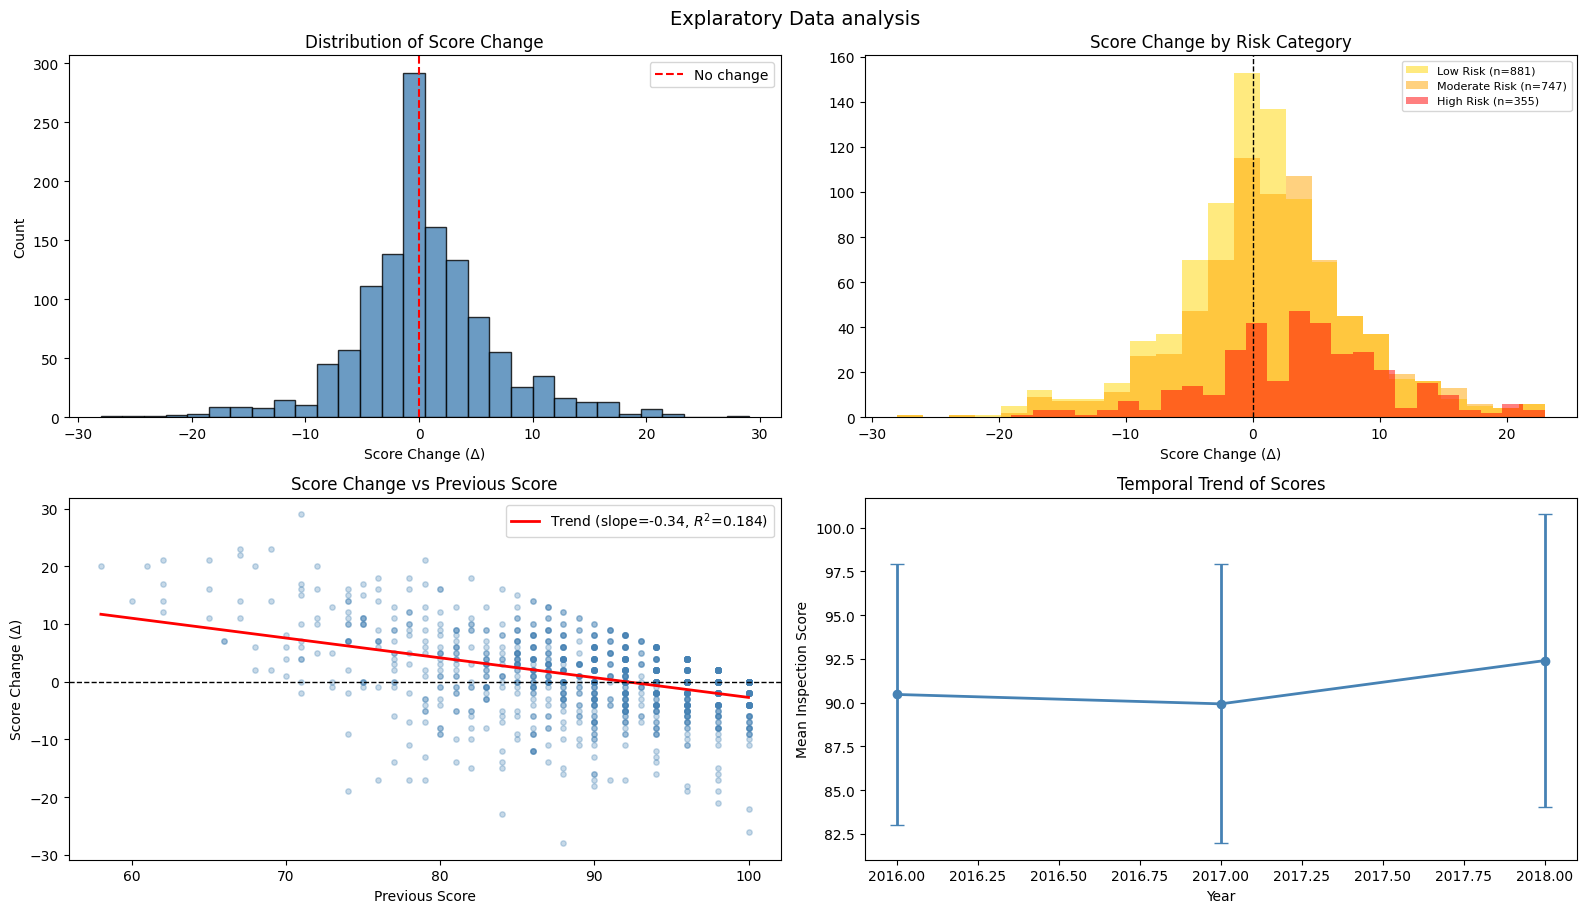

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# 1. Distribution of delta overall
axes[0, 0].hist(set_A['delta'], bins=30, edgecolor='black', color='steelblue', alpha=0.8)
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='No change')
axes[0, 0].set_xlabel('Score Change (Δ)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Distribution of Score Change')
axes[0, 0].legend()

# 2. Delta by risk category (motivates CQR: heteroscedasticity)
risk_labels = [
    ('has_low', 'Low Risk', 'gold'),
    ('has_moderate', 'Moderate Risk', 'orange'),
    ('has_high', 'High Risk', 'red')
]
for col, label, color in risk_labels:
    subset = set_A[set_A[col] == 1]['delta']
    axes[0, 1].hist(subset, bins=25, alpha=0.5, label=f'{label} (n={len(subset)})', color=color)
axes[0, 1].set_xlabel('Score Change (Δ)')
axes[0, 1].set_title('Score Change by Risk Category')
axes[0, 1].legend(fontsize=8)
axes[0, 1].axvline(0, color='black', linestyle='--', linewidth=1)

# 3. Score change vs previous score (regression to mean)
axes[1, 0].scatter(set_A['prev_score'], set_A['delta'], alpha=0.3, s=15, color='steelblue')
z = np.polyfit(set_A['prev_score'], set_A['delta'], 1)
p = np.poly1d(z)
xline = np.linspace(set_A['prev_score'].min(), set_A['prev_score'].max(), 100)
delta_pred = np.polyval(z, set_A['prev_score'])
ss_res = np.sum((set_A['delta'] - delta_pred) ** 2)
ss_tot = np.sum((set_A['delta'] - set_A['delta'].mean()) ** 2)
r2 = 1 - ss_res / ss_tot
axes[1, 0].plot(xline, p(xline), 'r-', linewidth=2, label=f'Trend (slope={z[0]:.2f}, $R^2$={r2:.3f})')
axes[1, 0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1, 0].set_xlabel('Previous Score')
axes[1, 0].set_ylabel('Score Change (Δ)')
axes[1, 0].set_title('Score Change vs Previous Score')
axes[1, 0].legend()

# 4. Temporal trend: average score by year
yearly = set_A.groupby('year')['prev_score'].agg(['mean', 'std']).reset_index()
axes[1, 1].errorbar(yearly['year'], yearly['mean'], yerr=yearly['std'],
                    fmt='o-', capsize=5, color='steelblue', linewidth=2)
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Mean Inspection Score')
axes[1, 1].set_title('Temporal Trend of Scores')

plt.tight_layout()
plt.suptitle('Explaratory Data analysis', fontsize=14, y=1.01)
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()


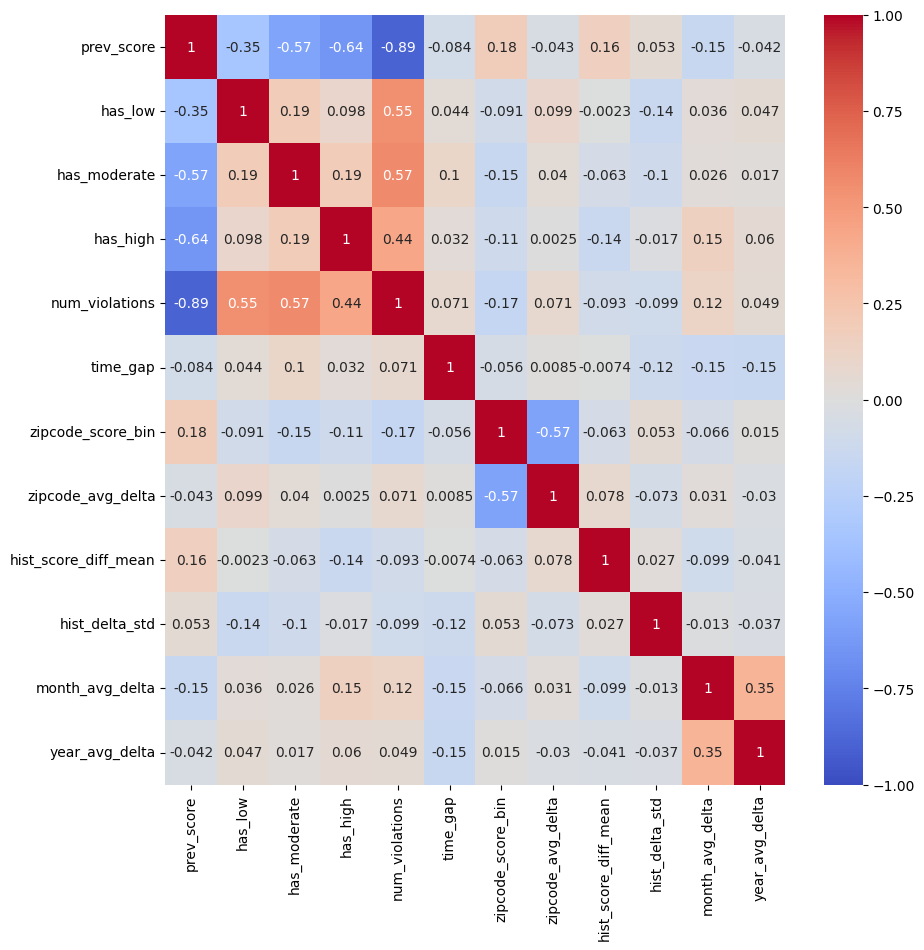

In [10]:
import seaborn as sns
plt.figure(figsize=(10, 10))
sns.heatmap(set_A[FEATURE_COLS].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.show()


---
# Part 1: Selective Inference

## Step 1.1: Knockoffs — FDR-Controlled Feature Selection

We construct Gaussian Model-X knockoffs (Chp 2.6) on Set A to identify which features predict $\Delta$, controlling FDR $\leq 0.2$.

**Assumption:** Features $X \sim \mathcal{N}(\mu, \Sigma)$. We acknowledge this is an approximation and we fit a Bernoulli distribution to the binary features.

In [11]:
from sklearn.linear_model import LogisticRegression

def construct_gaussian_knockoffs(X, seed=42):
    """
    Gaussian equicorrelated knockoffs.

    Sampling via the conditional:
        X_tilde | X ~ N(mu + (I - D @ Sigma_inv) @ (x - mu),
                        2*D - D @ Sigma_inv @ D)
    """
    rng = np.random.default_rng(seed)
    n, p = X.shape

    # Step 1: estimate mu and Sigma
    mu    = X.mean(axis=0)
    Sigma = np.cov(X.T)

    # Step 2: choose D = diag(s) via equicorrelated rule
    Sigma_corr = np.corrcoef(X.T)
    s_scalar   = min(2 * np.linalg.eigvalsh(Sigma_corr).min(), 1.0) * 0.99
    s          = s_scalar * np.diag(Sigma)
    D          = np.diag(s)

    # Step 3: build conditional distribution X_tilde | X
    Sigma_inv  = np.linalg.pinv(Sigma)

    # conditional mean
    mu_cond    = mu + (X - mu) @ (np.eye(p) - Sigma_inv @ D).T

    # conditional covariance
    Sigma_cond = 2 * D - D @ Sigma_inv @ D
    Sigma_cond = (Sigma_cond + Sigma_cond.T) / 2          
    eig_min    = np.linalg.eigvalsh(Sigma_cond).min()
    if eig_min < 0:
        Sigma_cond += (-eig_min + 1e-8) * np.eye(p)

    # Step 4: sample X_tilde for each row
    L       = np.linalg.cholesky(Sigma_cond)
    X_tilde = mu_cond + rng.standard_normal((n, p)) @ L.T

    return X_tilde, s, Sigma


def construct_mixed_knockoffs(X_std, X_raw, feature_names, seed=42):
    """
    Model-X knockoffs for mixed continuous / binary features

    - Continuous features: Gaussian equicorrelated knockoffs on X_std.
    - Binary features: X_tilde_j ~ Bernoulliu(p_hat) where p_hat = P(X_j=1 | X_{-j}) estimated by logistic regression, then re-standardised to match X_std scale.
    """
    rng   = np.random.default_rng(seed)
    n, p  = X_std.shape
    X_tilde = np.empty_like(X_std)

    # Classify features from raw values
    binary_idx, cont_idx = [], []
    for j in range(p):
        col = X_raw[:, j]
        if set(np.unique(col[~np.isnan(col)].astype(float))).issubset({0.0, 1.0}):
            binary_idx.append(j)
        else:
            cont_idx.append(j)

    print(f"  Binary features : {[feature_names[j] for j in binary_idx]}")
    print(f"  Continuous      : {[feature_names[j] for j in cont_idx]}")

    # Binary knockoffs: sample from P(X_j = 1 | X_{-j})
    col_mean = X_raw.mean(axis=0)
    col_std  = X_raw.std(axis=0).clip(min=1e-8)

    for j in binary_idx:
        col_raw = X_raw[:, j].astype(int)
        if len(np.unique(col_raw)) < 2:
            p_hat = np.full(n, col_raw.mean())
        else:
            lr = LogisticRegression(max_iter=500, C=1.0, random_state=seed)
            lr.fit(np.delete(X_raw, j, axis=1), col_raw)
            p_hat = lr.predict_proba(np.delete(X_raw, j, axis=1))[:, 1]
        knockoff_raw  = rng.binomial(1, p_hat).astype(float)
        X_tilde[:, j] = (knockoff_raw - col_mean[j]) / col_std[j]

    # Continuous knockoffs: Gaussian equicorrelated on standardised block
    if cont_idx:
        Xt_cont, s_vals, Sigma = construct_gaussian_knockoffs(
            X_std[:, cont_idx], seed=seed)
        for k, j in enumerate(cont_idx):
            X_tilde[:, j] = Xt_cont[:, k]
    else:
        s_vals, Sigma = np.array([]), np.eye(1)

    return X_tilde, s_vals, Sigma, binary_idx, cont_idx


def knockoff_threshold_path(Z_orig, Z_tilde, fdr_level=0.2):
    """
    Knockoff threshold using Lasso path entry-time statistics.

    FDP_hat(t) = #{knockoffs in S_t} / #{originals in S_t}
    T = min{ t : FDP_hat(t) <= fdr_level }
    """
    candidates = np.sort(np.unique(np.concatenate([
        Z_orig[Z_orig > 0], Z_tilde[Z_tilde > 0]
    ])))
    for t in candidates:
        n_orig  = int(np.sum((Z_orig  >= t) & (Z_orig  > Z_tilde)))
        n_knock = int(np.sum((Z_tilde >= t) & (Z_tilde > Z_orig)))
        if n_orig == 0:
            continue
        if n_knock / n_orig <= fdr_level:
            return t, np.where((Z_orig >= t) & (Z_orig > Z_tilde))[0]
    return np.inf, np.array([], dtype=int)


In [12]:
# Prepare Set A feature matrix
X_A = set_A[FEATURE_COLS].values.astype(float)
y_A = set_A['delta'].values.astype(float)

# Remove any rows with NaN
valid_mask = ~(np.isnan(X_A).any(axis=1) | np.isnan(y_A))
X_A, y_A   = X_A[valid_mask], y_A[valid_mask]
print(f'Set A after dropping NaN: {X_A.shape}')
1
# Standardize features
scaler = StandardScaler()
X_A_std = scaler.fit_transform(X_A)

Set A after dropping NaN: (1253, 12)


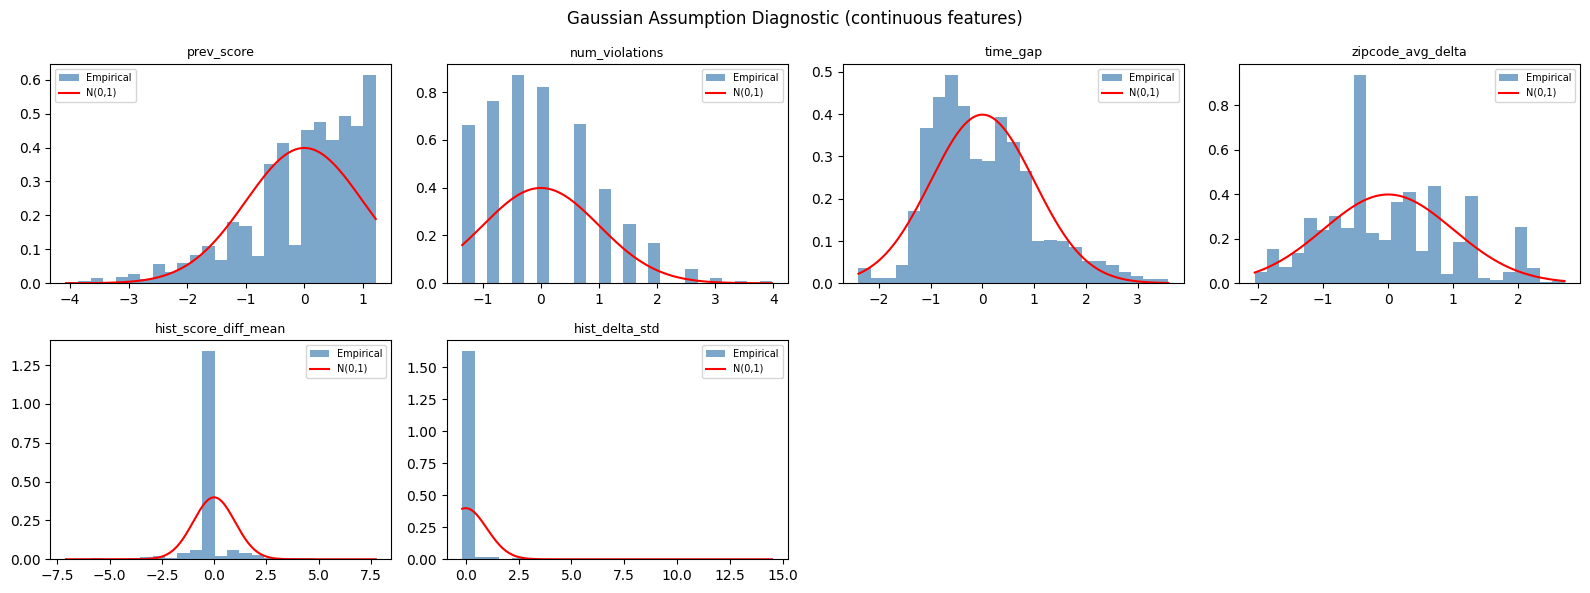

In [13]:
# Diagnostic: validate Gaussian approximation for P_X 
binary_feats = {'has_low', 'has_moderate', 'has_high', 'zipcode_score_bin', 'month_avg_delta', 'year_avg_delta'}
cont_cols = [f for f in FEATURE_COLS if f not in binary_feats]
cont_idx_diag = [FEATURE_COLS.index(f) for f in cont_cols]

ncols = 4
nrows = -(-len(cont_cols) // ncols)  
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()

for k, (feat, idx) in enumerate(zip(cont_cols, cont_idx_diag)):
    axes[k].hist(X_A_std[:, idx], bins=25, density=True,
                 color='steelblue', alpha=0.7, label='Empirical')
    xs = np.linspace(X_A_std[:, idx].min(), X_A_std[:, idx].max(), 200)
    axes[k].plot(xs, stats.norm.pdf(xs), 'r-', linewidth=1.5, label='N(0,1)')
    axes[k].set_title(feat, fontsize=9)
    axes[k].legend(fontsize=7)

for j in range(len(cont_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Gaussian Assumption Diagnostic (continuous features)', fontsize=12)
plt.tight_layout()
plt.savefig('knockoff_gaussian_diag.png', dpi=100, bbox_inches='tight')
plt.show()

In [14]:
# Construct mixed knockoffs
print("Knockoff construction (mixed types):")
X_A_tilde, s_vals, Sigma_A, binary_idx, cont_idx = construct_mixed_knockoffs(
    X_A_std, X_A, FEATURE_COLS, seed=42
)

Knockoff construction (mixed types):
  Binary features : ['has_low', 'has_moderate', 'has_high']
  Continuous      : ['prev_score', 'num_violations', 'time_gap', 'zipcode_score_bin', 'zipcode_avg_delta', 'hist_score_diff_mean', 'hist_delta_std', 'month_avg_delta', 'year_avg_delta']


In [15]:
from sklearn.linear_model import lasso_path

# Augmented feature matrix
X_aug = np.hstack([X_A_std, X_A_tilde])
p     = len(FEATURE_COLS)

# Compute full Lasso regularization path on the augmented matrix.
alphas, coefs_path, _ = lasso_path(X_aug, y_A, max_iter=10000, eps=1e-4)

Z = np.zeros(2 * p)
for j in range(2 * p):
    first_nonzero = np.where(np.abs(coefs_path[j, :]) > 1e-10)[0]
    if len(first_nonzero) > 0:
        Z[j] = alphas[first_nonzero[0]]  # highest lambda where coef is nonzero = entry point

Z_orig  = Z[:p]   # entry lambdas for original features
Z_tilde = Z[p:]   # entry lambdas for knockoff copies
W_path  = Z_orig - Z_tilde  # positive = original entered before knockoff

print(f'Lasso path: {len(alphas)} steps, lambda range [{alphas[-1]:.5f}, {alphas[0]:.4f}]')
print(f'Features that never entered the model: {[FEATURE_COLS[j] for j in range(p) if Z_orig[j] == 0]}')
print()
print(f'  {"Feature":25s}  {"Z_orig":8s}  {"Z_tilde":8s}  {"W = Z-Z̃":8s}  {"entered first"}')
print('  ' + '-'*72)
for feat, zo, zt, w in zip(FEATURE_COLS, Z_orig, Z_tilde, W_path):
    winner = 'ORIGINAL' if zo > zt else ('knockoff' if zt > zo else 'tie')
    print(f'  {feat:25s}  {zo:8.5f}  {zt:8.5f}  {w:+8.5f}  {winner}')


Lasso path: 100 steps, lambda range [0.00027, 2.7226]
Features that never entered the model: []

  Feature                    Z_orig    Z_tilde   W = Z-Z̃  entered first
  ------------------------------------------------------------------------
  prev_score                  2.48077   0.11515  +2.36563  ORIGINAL
  has_low                     0.42356   0.20122  +0.22233  ORIGINAL
  has_moderate                0.07232   0.15222  -0.07990  knockoff
  has_high                    0.67442   0.04542  +0.62900  ORIGINAL
  num_violations              0.06004   0.03771  +0.02233  ORIGINAL
  time_gap                    0.38593   0.07937  +0.30656  ORIGINAL
  zipcode_score_bin           0.05470   0.46485  -0.41015  knockoff
  zipcode_avg_delta           0.35164   0.35164  +0.00000  tie
  hist_score_diff_mean        0.74018   0.00644  +0.73374  ORIGINAL
  hist_delta_std              0.20122   0.00231  +0.19891  ORIGINAL
  month_avg_delta             0.38593   0.12637  +0.25955  ORIGINAL
  year_avg_d

Knockoff threshold T = 0.20122327157649317
Selected features (FDR <= 0.2): ['prev_score', 'has_low', 'has_high', 'time_gap', 'hist_score_diff_mean', 'hist_delta_std', 'month_avg_delta', 'year_avg_delta']
Number of selected features: 8


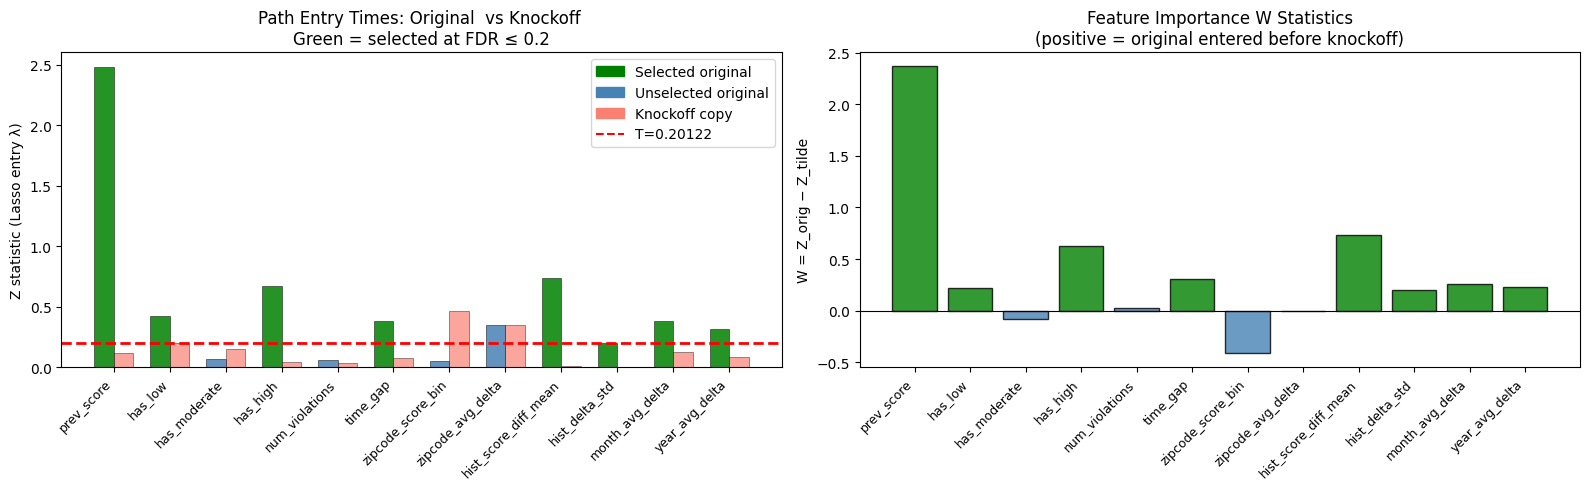

In [16]:
from matplotlib.patches import Patch

# Apply knockoff threshold 
T_knockoff, selected_idx = knockoff_threshold_path(Z_orig, Z_tilde, fdr_level=FDR_LEVEL)
selected_features = [FEATURE_COLS[i] for i in selected_idx]

print(f'Knockoff threshold T = {T_knockoff}')
print(f'Selected features (FDR <= {FDR_LEVEL}): {selected_features}')
print(f'Number of selected features: {len(selected_features)}')

p   = len(FEATURE_COLS)
x   = np.arange(p)
w   = 0.35
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx in range(p):
    c_o = 'green' if idx in selected_idx else 'steelblue'
    axes[0].bar(idx - w/2, Z_orig[idx],  width=w, color=c_o,     alpha=0.85, edgecolor='black', linewidth=0.4)
    axes[0].bar(idx + w/2, Z_tilde[idx], width=w, color='salmon', alpha=0.70, edgecolor='black', linewidth=0.4)
if np.isfinite(T_knockoff):
    axes[0].axhline(T_knockoff, color='red', linestyle='--', linewidth=2,
                    label=f'Threshold T = {T_knockoff:.5f}')
    axes[0].legend()
axes[0].set_xticks(x)
axes[0].set_xticklabels(FEATURE_COLS, rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Z statistic (Lasso entry λ)')
axes[0].set_title(f'Path Entry Times: Original  vs Knockoff \nGreen = selected at FDR ≤ {FDR_LEVEL}')
axes[0].legend(handles=[
    Patch(color='green',   label='Selected original'),
    Patch(color='steelblue', label='Unselected original'),
    Patch(color='salmon',  label='Knockoff copy'),
] + ([plt.Line2D([0],[0], color='red', linestyle='--', label=f'T={T_knockoff:.5f}')] if np.isfinite(T_knockoff) else []))

# Right: W = Z_orig - Z_tilde
colors_w = ['green' if i in selected_idx else 'steelblue' for i in range(p)]
axes[1].bar(x, W_path, color=colors_w, edgecolor='black', alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(FEATURE_COLS, rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('W = Z_orig − Z_tilde')
axes[1].set_title('Feature Importance W Statistics\n(positive = original entered before knockoff)')

plt.tight_layout()
plt.savefig('knockoff_W_stats.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Step 1.2: FCR-Controlling Confidence Intervals

After knockoffs select $\hat{S}$, we report confidence intervals for the regression coefficients $\beta_j$, $j \in \hat{S}$, at the FCR-adjusted level $1 - \alpha \hat{K}/m$, where $\hat{K} = |\hat{S}|$ and $m$ is the total number of features.

In [17]:
m      = len(FEATURE_COLS)
K_hat  = len(selected_features)
alpha_fcr = FCR_ALPHA * K_hat / m

print(f'FCR adjustment: alpha_fcr = {FCR_ALPHA} * {K_hat} / {m} = {alpha_fcr:.4f}')
print(f'CI level: 1 - alpha_fcr = {1 - alpha_fcr:.4f}\n')

if K_hat > 0:
    X_sel = X_A[:, selected_idx]   # use unstandardized for interpretability
    X_sel_const = sm.add_constant(X_sel)
    ols_model = sm.OLS(y_A, X_sel_const).fit()

    ci = ols_model.conf_int(alpha=alpha_fcr)
    coef_names = ['intercept'] + selected_features

    print(f'OLS on selected features with FCR-adjusted CIs (level = {1-alpha_fcr:.3f}):')
    print(f'{"Feature":25s}  {"Coef":8s}  {"CI Lower":10s}  {"CI Upper":10s}  {"p-value":8s}')
    print('-' * 70)
    for i, name in enumerate(coef_names):
        print(f'{name:25s}  {ols_model.params[i]:8.4f}  '
              f'{ci[i, 0]:10.4f}  {ci[i, 1]:10.4f}  '
              f'{ols_model.pvalues[i]:8.4f}')
    print(f'\nModel R²: {ols_model.rsquared:.4f}')

FCR adjustment: alpha_fcr = 0.1 * 8 / 12 = 0.0667
CI level: 1 - alpha_fcr = 0.9333

OLS on selected features with FCR-adjusted CIs (level = 0.933):
Feature                    Coef      CI Lower    CI Upper    p-value 
----------------------------------------------------------------------
intercept                   32.6352     27.4215     37.8489    0.0000
prev_score                  -0.3400     -0.3923     -0.2877    0.0000
has_low                     -1.3377     -2.0372     -0.6383    0.0005
has_high                     0.4838     -0.3776      1.3452    0.3028
time_gap                    -0.0029     -0.0053     -0.0005    0.0281
hist_score_diff_mean        -0.2084     -0.3088     -0.1080    0.0001
hist_delta_std               0.1405     -0.1159      0.3968    0.3148
month_avg_delta              0.1540     -0.1276      0.4355    0.3157
year_avg_delta               0.3793     -0.1281      0.8868    0.1703

Model R²: 0.2143


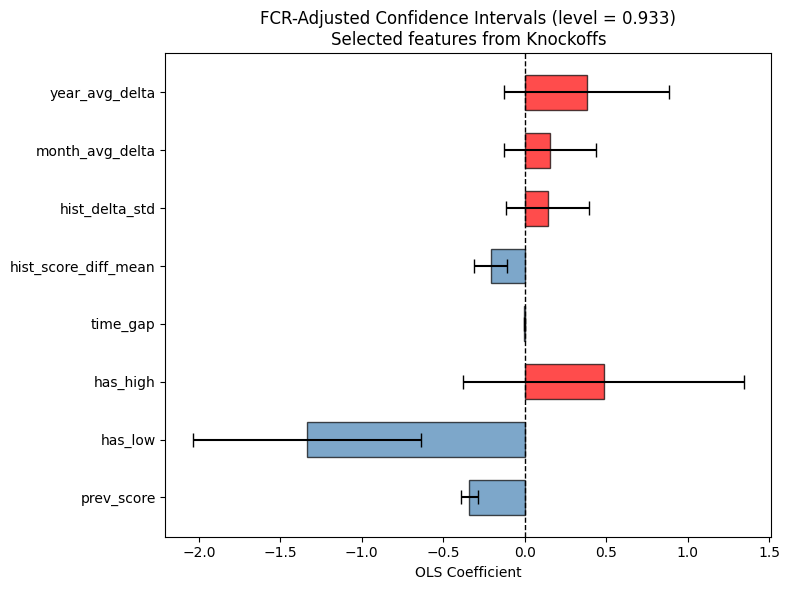

In [18]:
# Visualize FCR CIs
if K_hat > 0:
    fig, ax = plt.subplots(figsize=(8, max(4, K_hat * 0.5 + 2)))
    coefs_plot  = ols_model.params[1:]   # exclude intercept
    ci_plot     = ci[1:]            # exclude intercept
    y_pos = range(len(selected_features))

    ax.barh(y_pos, coefs_plot,
            xerr=[coefs_plot - ci_plot[:, 0], ci_plot[:, 1] - coefs_plot],
            color=['red' if c > 0 else 'steelblue' for c in coefs_plot],
            alpha=0.7, capsize=5, height=0.6, edgecolor='black')
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(selected_features)
    ax.set_xlabel('OLS Coefficient')
    ax.set_title(f'FCR-Adjusted Confidence Intervals (level = {1-alpha_fcr:.3f})\nSelected features from Knockoffs')
    plt.tight_layout()
    plt.savefig('fcr_cis.png', dpi=120, bbox_inches='tight')
    plt.show()

---
# Part 2: Predictive Inference
## Step 2.1: Conformalized Prediction Intervals

We reuse the OLS model µ̂(x) from Phase 1 for prediction.

From **PSet5 §3b**: fit µ̂ and σ̂ on the training data, calibrate rescaled residuals |y − µ̂(x)| / σ̂(x) on held-out data, and output adaptive confidence intervals.


Set B calibration size : 1266
sigma_hat (Set B): mean=4.124, std=1.210


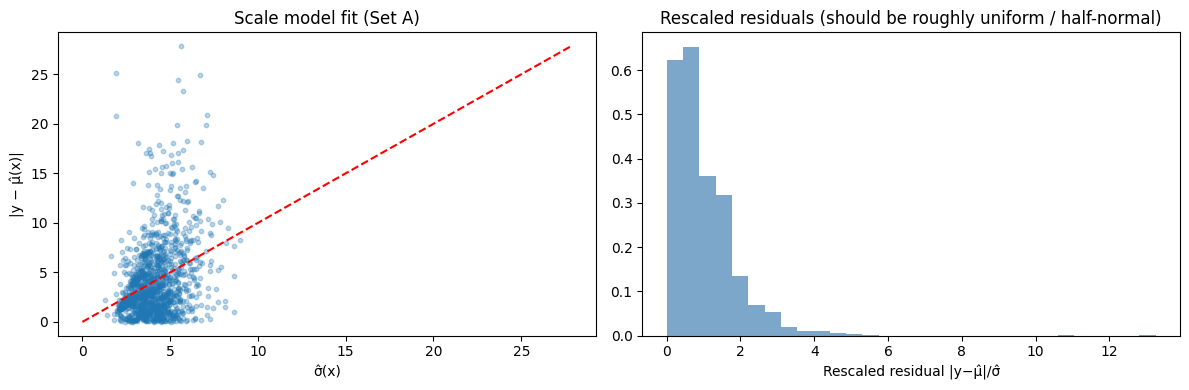

In [19]:
from sklearn.linear_model import LinearRegression

# ── Prepare feature matrices (unstandardised, selected features only) ──
X_A_sel  = X_A[:, selected_idx]
X_B_raw  = set_B[FEATURE_COLS].values.astype(float)
y_B      = set_B['delta'].values.astype(float)
rest_ids_B = set_B['business_id'].values

valid_B  = ~(np.isnan(X_B_raw).any(axis=1) | np.isnan(y_B))
X_B_raw, y_B, rest_ids_B = X_B_raw[valid_B], y_B[valid_B], rest_ids_B[valid_B]
X_B_sel  = X_B_raw[:, selected_idx]

# ── µ̂: predictions from the Phase-1 OLS model ──
mu_hat_A  = ols_model.predict(sm.add_constant(X_A_sel,  has_constant='add'))
mu_hat_B  = ols_model.predict(sm.add_constant(X_B_sel,  has_constant='add'))

# ── σ̂: fit conditional scale on Set A residuals (same as PSet5 §3b) ──
abs_resid_A = np.abs(y_A - mu_hat_A)
sigma_model = LinearRegression().fit(X_A_sel, abs_resid_A)

sigma_A = np.maximum(sigma_model.predict(X_A_sel), 1e-3)
sigma_B = np.maximum(sigma_model.predict(X_B_sel), 1e-3)

print(f'Set B calibration size : {len(y_B)}')
print(f'sigma_hat (Set B): mean={sigma_B.mean():.3f}, std={sigma_B.std():.3f}')

# Diagnostic: sigma_hat vs |residual| on Set A
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(sigma_A, abs_resid_A, alpha=0.3, s=10)
axes[0].plot([0, abs_resid_A.max()], [0, abs_resid_A.max()], 'r--')
axes[0].set_xlabel('σ̂(x)'); axes[0].set_ylabel('|y − µ̂(x)|')
axes[0].set_title('Scale model fit (Set A)')

rescaled_A = abs_resid_A / sigma_A
axes[1].hist(rescaled_A, bins=30, density=True, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Rescaled residual |y−µ̂|/σ̂')
axes[1].set_title('Rescaled residuals (should be roughly uniform / half-normal)')
plt.tight_layout(); plt.show()


In [20]:
# ── Calibrate rescaled residuals on Set B ──
rescaled_B = np.abs(y_B - mu_hat_B) / sigma_B
n_cal      = len(rescaled_B)
q_hat      = np.quantile(rescaled_B,
                          (1 - COVERAGE_ALPHA) * (1 + 1 / n_cal),
                          method='higher')

print(f'Calibration quantile q_hat = {q_hat:.4f}')
print(f'Rescaled residuals: mean={rescaled_B.mean():.3f}, '
      f'90th pct={np.quantile(rescaled_B, 0.9):.3f}')

# ── Plain (non-rescaled) conformal as baseline ──
plain_resid_B = np.abs(y_B - mu_hat_B)
q_hat_plain   = np.quantile(plain_resid_B,
                              (1 - COVERAGE_ALPHA) * (1 + 1 / n_cal),
                              method='higher')
print(f'Plain conformal q_hat      = {q_hat_plain:.4f}')


Calibration quantile q_hat = 2.3015
Rescaled residuals: mean=0.960, 90th pct=1.912
Plain conformal q_hat      = 10.6243


---
## Step 2.2: Conformalized Quantile Regression (CQR)

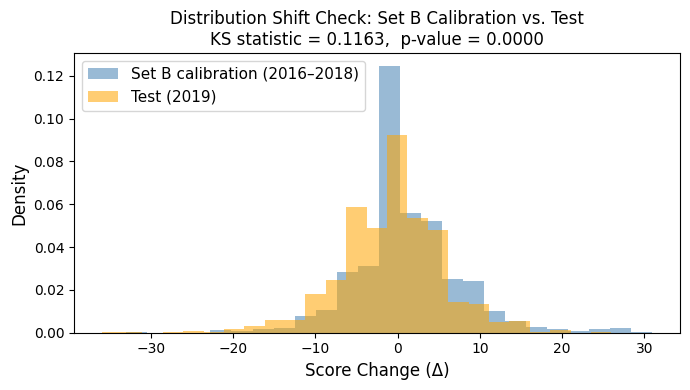


KS test (Set B vs 2019): statistic=0.1163, p-value=0.0000
→ Evidence of distribution shift between calibration and test samples.
  Exact exchangeability is questionable for 2019 coverage evaluation.
  Adaptive methods (CQR, kNN conformal) may improve empirical performance.


In [21]:
# ── Distribution Shift Check (Set B calibration vs. 2019 test) ──────────
all_for_ks = set_B['delta'].dropna()
test_ks    = pairs_test['delta'].dropna()

ks_stat, ks_pval = stats.ks_2samp(all_for_ks, test_ks)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(all_for_ks, bins=25, alpha=0.55, label='Set B calibration (2016–2018)',
        color='steelblue', density=True)
ax.hist(test_ks,    bins=25, alpha=0.55, label='Test (2019)',
        color='orange',    density=True)
ax.set_xlabel('Score Change (Δ)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(
    f'Distribution Shift Check: Set B Calibration vs. Test\n'
    f'KS statistic = {ks_stat:.4f},  p-value = {ks_pval:.4f}',
    fontsize=12
)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('distribution_shift_check.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nKS test (Set B vs 2019): statistic={ks_stat:.4f}, p-value={ks_pval:.4f}')
if ks_pval < 0.05:
    print('→ Evidence of distribution shift between calibration and test samples.')
    print('  Exact exchangeability is questionable for 2019 coverage evaluation.')
    print('  Adaptive methods (CQR, kNN conformal) may improve empirical performance.')
else:
    print('→ No strong evidence of shift. Exchangeability looks more plausible.')

# ── Test set setup ───────────────────────────────────────────────────────────
X_test_all = pairs_test[FEATURE_COLS].values.astype(float)
y_test_raw = pairs_test['delta'].values.astype(float)
valid_test  = ~(np.isnan(X_test_all).any(axis=1) | np.isnan(y_test_raw))
X_test_all, y_test = X_test_all[valid_test], y_test_raw[valid_test]
pairs_test_valid = pairs_test[valid_test].copy()
X_test_sel = X_test_all[:, selected_idx]

mu_hat_te  = ols_model.predict(sm.add_constant(X_test_sel, has_constant='add'))
sigma_te   = np.maximum(sigma_model.predict(X_test_sel), 1e-3)

# Rescaled and plain intervals
lower_rs = mu_hat_te - q_hat       * sigma_te
upper_rs = mu_hat_te + q_hat       * sigma_te
lower_pl = mu_hat_te - q_hat_plain * np.ones(len(mu_hat_te))
upper_pl = mu_hat_te + q_hat_plain * np.ones(len(mu_hat_te))

In [22]:
#  Conformalized Quantile Regression (CQR)

X_A_const  = sm.add_constant(X_A_sel,    has_constant='add')
X_B_const  = sm.add_constant(X_B_sel,    has_constant='add')
X_te_const = sm.add_constant(X_test_sel, has_constant='add')

q_lo_model = QuantReg(y_A, X_A_const).fit(q=COVERAGE_ALPHA / 2,     max_iter=2000)
q_hi_model = QuantReg(y_A, X_A_const).fit(q=1 - COVERAGE_ALPHA / 2, max_iter=2000)

# Calibrate CQR score on Set B
gamma_lo_B   = q_lo_model.predict(X_B_const)
gamma_hi_B   = q_hi_model.predict(X_B_const)
cqr_scores_B = np.maximum(y_B - gamma_hi_B, gamma_lo_B - y_B)
q_hat_cqr    = np.quantile(cqr_scores_B,
                            (1 - COVERAGE_ALPHA) * (1 + 1 / n_cal),
                            method='higher')

# Test set intervals
gamma_lo_te = q_lo_model.predict(X_te_const)
gamma_hi_te = q_hi_model.predict(X_te_const)
lower_cqr   = gamma_lo_te - q_hat_cqr
upper_cqr   = gamma_hi_te + q_hat_cqr

print(f'CQR calibration quantile q̂  = {q_hat_cqr:.4f}')
print(f'CQR avg interval width       = {(upper_cqr - lower_cqr).mean():.4f}')
print(f'Quantile lo (test): mean={gamma_lo_te.mean():.3f}   '
      f'Quantile hi (test): mean={gamma_hi_te.mean():.3f}')

CQR calibration quantile q̂  = 0.0000
CQR avg interval width       = 22.4487
Quantile lo (test): mean=-13.091   Quantile hi (test): mean=9.357


---
## Step 2.3: Local (k-Nearest-Neighbor) Conformal Prediction

Instead of a single global quantile over all calibration points, we compute a **local quantile** for each test point from its $k$ nearest neighbors in the calibration set.

**Procedure:**
1. For each test point $x_\text{te}$, find its $k$ nearest neighbors $\mathcal{N}(x_\text{te}) \subseteq \mathcal{B}$ (standardised feature space).
2. Compute the local conformal quantile from the $k$ neighbors' rescaled nonconformity scores $s_i = |y_i - \hat\mu(x_i)|/\hat\sigma(x_i)$.
3. Prediction interval: $\hat\mu(x_\text{te}) \pm \hat{q}_k(x_\text{te})\cdot\hat\sigma(x_\text{te})$.

In [23]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# Standardise selected features for distance computation 
scaler_knn  = StandardScaler().fit(X_B_sel)
X_B_scaled  = scaler_knn.transform(X_B_sel)
X_te_scaled = scaler_knn.transform(X_test_sel)

# Try different values of k
K_values = [20, 30, 50, 100, 200, 500, 1000]

knn_results = {}
print(f'kNN local conformal (target coverage >= {1-COVERAGE_ALPHA:.2f})')
print(f'{"k":>6}  {"coverage":>9}  {"avg width":>10}')
print('-' * 32)

for K in K_values:
    nn = NearestNeighbors(n_neighbors=K).fit(X_B_scaled)
    _, idx = nn.kneighbors(X_te_scaled)   # (n_test, K)

    level   = (1 - COVERAGE_ALPHA) * (1 + 1 / K)
    q_local = np.array([
        np.quantile(rescaled_B[idx[i]], level, method='higher')
        for i in range(len(X_te_scaled))
    ])

    lower_k = mu_hat_te - q_local * sigma_te
    upper_k = mu_hat_te + q_local * sigma_te

    covered = (y_test >= lower_k) & (y_test <= upper_k)
    cov   = covered.mean()
    width = (upper_k - lower_k).mean()
    print(f'{K:>6}  {cov:>9.4f}  {width:>10.4f}')
    knn_results[K] = dict(lower=lower_k, upper=upper_k,
                          covered=covered, cov=cov, width=width,
                          q_local=q_local)

# Pick k closest to nominal coverage, here we may have to consider some multiplicity correction
K_best      = min(K_values, key=lambda k: abs(knn_results[k]['cov'] - (1 - COVERAGE_ALPHA)))
lower_knn   = knn_results[K_best]['lower']
upper_knn   = knn_results[K_best]['upper']
cov_knn     = knn_results[K_best]['cov']
width_knn   = knn_results[K_best]['width']
covered_knn = knn_results[K_best]['covered']
q_local_best = knn_results[K_best]['q_local']
print(f'\nSelected k = {K_best}  (coverage = {cov_knn:.4f}, avg width = {width_knn:.4f})')


kNN local conformal (target coverage >= 0.95)
     k   coverage   avg width
--------------------------------
    20     0.9258     24.0558
    30     0.9445     27.2702
    50     0.9390     24.1208


   100     0.9252     20.5989


   200     0.9241     19.6046


   500     0.9225     19.4980


  1000     0.9263     19.4778

Selected k = 30  (coverage = 0.9445, avg width = 27.2702)


---
## Part 3: Evaluation on 2019 Test Set

In [24]:
def coverage_and_width(lower, upper, y_true, label=""):
    covered = (y_true >= lower) & (y_true <= upper)
    cov   = covered.mean()
    width = (upper - lower).mean()
    print(f'{label:45s}: coverage = {cov:.4f},  avg width = {width:.4f}')
    return covered, cov, width

print("=" * 78)
print(f"Target coverage = {1-COVERAGE_ALPHA:.2f}   (exact under exchangeability for split conformal)")
print("=" * 78)

covered_rs,  cov_rs,  width_rs  = coverage_and_width(lower_rs,  upper_rs,  y_test,
                                                       "Rescaled conformal (OLS + σ̂)")
covered_pl,  cov_pl,  width_pl  = coverage_and_width(lower_pl,  upper_pl,  y_test,
                                                       "Plain conformal (fixed width)")
covered_cqr, cov_cqr, width_cqr = coverage_and_width(lower_cqr, upper_cqr, y_test,
                                                       "CQR (conformalized quantile regression)")
covered_knn2, cov_knn2, width_knn2 = coverage_and_width(lower_knn, upper_knn, y_test,
                                                          f"kNN conformal (k={K_best})")


Target coverage = 0.95   (exact under exchangeability for split conformal)
Rescaled conformal (OLS + σ̂)                : coverage = 0.9274,  avg width = 19.4519
Plain conformal (fixed width)                : coverage = 0.9318,  avg width = 21.2485
CQR (conformalized quantile regression)      : coverage = 0.9241,  avg width = 22.4487
kNN conformal (k=30)                         : coverage = 0.9445,  avg width = 27.2702


In [25]:
# Coverage by risk category
print('\nCoverage by risk category (Rescaled conformal):')
for col, name in zip(['has_low','has_moderate','has_high'],
                     ['Low Risk','Moderate Risk','High Risk']):
    mask = pairs_test_valid[col].values.astype(bool)
    if mask.sum() == 0: continue
    cov_r = covered_rs[mask].mean()
    w_r   = (upper_rs[mask] - lower_rs[mask]).mean()
    print(f'  {name:15s}: coverage={cov_r:.4f}, avg width={w_r:.4f}, n={mask.sum()}')



Coverage by risk category (Rescaled conformal):
  Low Risk       : coverage=0.9341, avg width=21.2463, n=1290
  Moderate Risk  : coverage=0.9298, avg width=21.6999, n=1139
  High Risk      : coverage=0.9170, avg width=23.0140, n=506


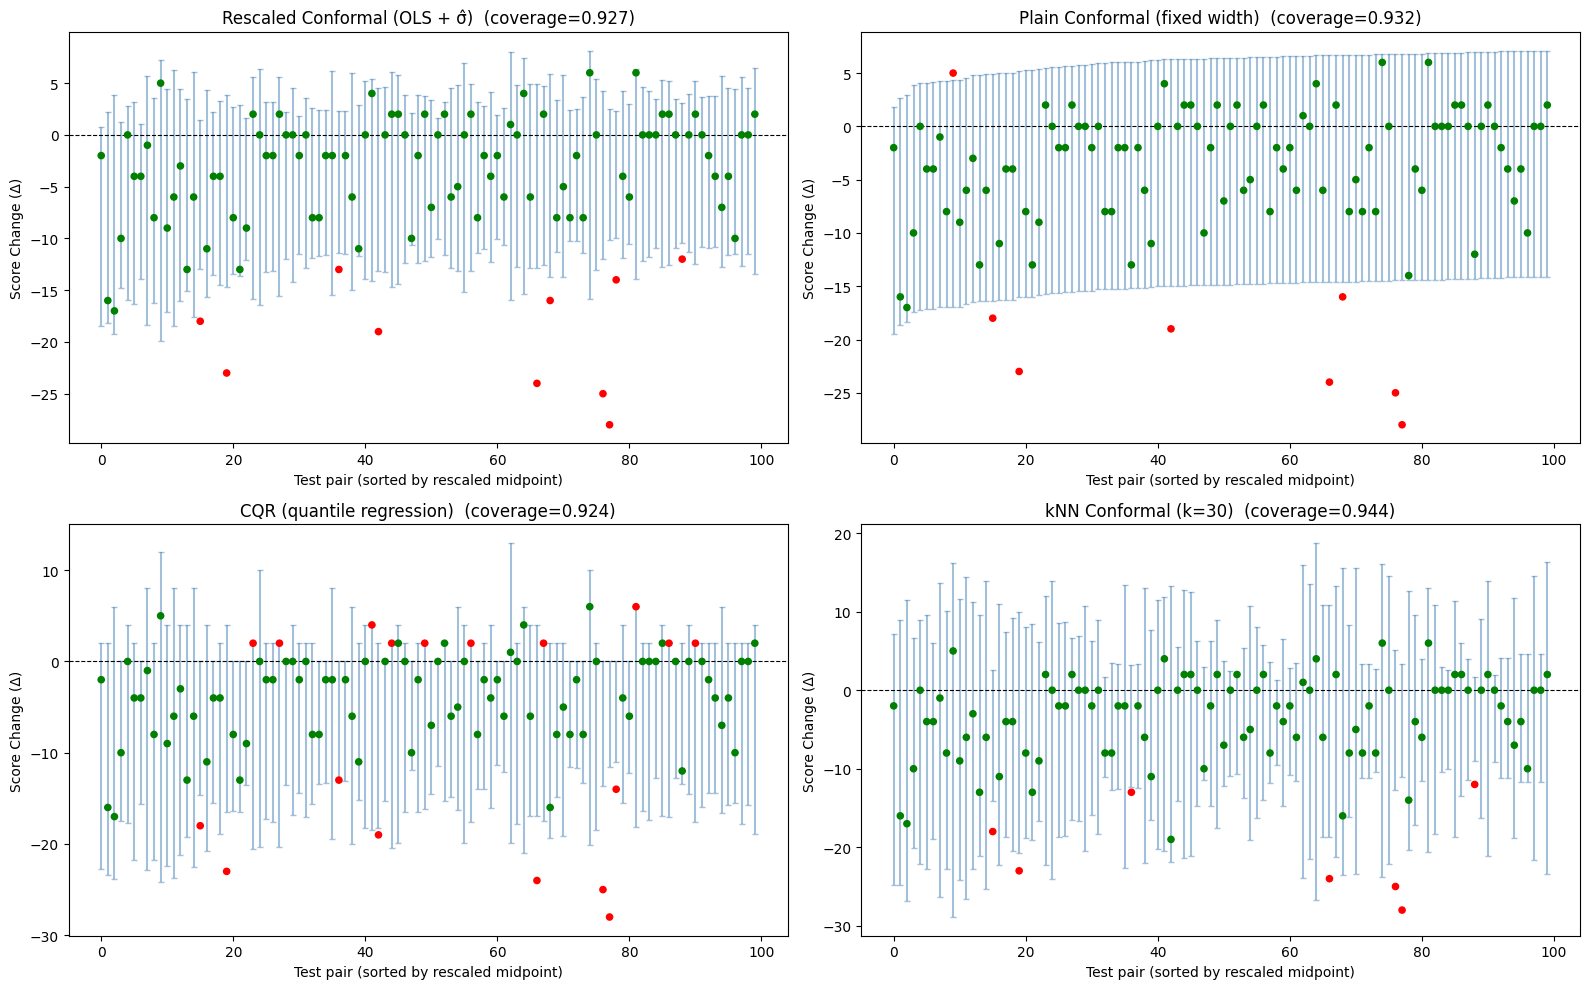

In [26]:
# Visualisation: prediction intervals vs actual delta — all four methods
methods = [
    ('Rescaled Conformal (OLS + σ̂)', lower_rs,  upper_rs,  covered_rs,  cov_rs),
    ('Plain Conformal (fixed width)',  lower_pl,  upper_pl,  covered_pl,  cov_pl),      
    ('CQR (quantile regression)',      lower_cqr, upper_cqr, covered_cqr, cov_cqr),
    (f'kNN Conformal (k={K_best})',    lower_knn, upper_knn, covered_knn, cov_knn2),
]

# Common ordering across all panels (sort by rescaled midpoint)
mid_ref = (lower_rs + upper_rs) / 2
order   = np.argsort(mid_ref)[:100]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (title, lo, hi, covered, cov) in zip(axes.flat, methods):
    mid = (lo + hi) / 2
    ax.errorbar(range(len(order)), mid[order],
                yerr=[mid[order]-lo[order], hi[order]-mid[order]],
                fmt="none", ecolor="steelblue", alpha=0.5, capsize=2)
    ax.scatter(range(len(order)), y_test[order],
               c=["green" if c else "red" for c in covered[order]],
               s=20, zorder=5)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Test pair (sorted by rescaled midpoint)")
    ax.set_ylabel("Score Change (Δ)")
    ax.set_title(f"{title}  (coverage={cov:.3f})")

plt.tight_layout()
plt.savefig("evaluation_results.png", dpi=120, bbox_inches="tight")
plt.show()

In [27]:
print("=" * 68)
print("FINAL RESULTS SUMMARY")
print("=" * 68)
print(f"\nPhase 1 — Knockoffs (FDR ≤ {FDR_LEVEL})")
print(f"  Selected features : {selected_features}")
print(f"  Threshold T       = {T_knockoff:.4f}")
print(f"\nPhase 1 — FCR CIs (level {1-alpha_fcr:.3f})")
if K_hat > 0:
    print(f"  OLS R²            = {ols_model.rsquared:.4f}")

print(f"\nPhase 2 — Prediction Intervals on 2019 Test Set")
print(f"  {'Method':<45} {'Coverage':>9} {'Avg Width':>11}")
print(f"  {'-'*67}")
for label, cov, width in [
    ("Rescaled conformal (OLS + σ̂)",              cov_rs,  width_rs),
    ("Plain conformal (fixed width)",              cov_pl,  width_pl),
    ("CQR (conformalized quantile regression)",    cov_cqr, width_cqr),
    (f"kNN conformal (k={K_best})",                cov_knn, width_knn)
]:
    print(f"  {label:<45} {cov:>9.4f} {width:>11.4f}")

print("\nLimitations:")
print("  1. Binary/discrete features violate Gaussian knockoff assumption")
print("     (mitigated: binary features use Bernoulli knockoffs)")
print("  2. Gaussian knockoff validity requires Gaussian X — noted as approximation")
print("  3. Temporal distribution shift from Set B to 2019 weakens the")
print("     exchangeability-based coverage guarantee for all split conformal methods;")
print("     CQR and kNN may adapt better empirically, but do not restore the guarantee")
print("  4. OLS mean model has limited predictive power (low R²);")
print("     a richer base model would narrow all intervals")
print("  5. kNN locality is limited by the quality of the feature space —")
print("     temporal features (year, month) are absent from the distance metric")

FINAL RESULTS SUMMARY

Phase 1 — Knockoffs (FDR ≤ 0.2)
  Selected features : ['prev_score', 'has_low', 'has_high', 'time_gap', 'hist_score_diff_mean', 'hist_delta_std', 'month_avg_delta', 'year_avg_delta']
  Threshold T       = 0.2012

Phase 1 — FCR CIs (level 0.933)
  OLS R²            = 0.2143

Phase 2 — Prediction Intervals on 2019 Test Set
  Method                                         Coverage   Avg Width
  -------------------------------------------------------------------
  Rescaled conformal (OLS + σ̂)                    0.9274     19.4519
  Plain conformal (fixed width)                    0.9318     21.2485
  CQR (conformalized quantile regression)          0.9241     22.4487
  kNN conformal (k=30)                             0.9445     27.2702

Limitations:
  1. Binary/discrete features violate Gaussian knockoff assumption
     (mitigated: binary features use Bernoulli knockoffs)
  2. Gaussian knockoff validity requires Gaussian X — noted as approximation
  3. Temporal dist